# Pneumonia Detection from Chest X-Rays
**Dataset**: RSNA Pneumonia Detection Challenge (DICOM chest X-rays)

**Goal**: Binary classification — pneumonia-positive vs. pneumonia-negative

---
## Section 1: Data Overview

In [1]:
# Imports and project-wide constants.
# Run this cell first — every subsequent cell depends on state defined here.
import os
import zipfile
import random
import pandas as pd
import numpy as np
import pydicom
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fix all random seeds so the train/val/test split, shuffle order,
# and Dropout masks are reproducible across kernel restarts.
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

DATA_DIR   = "data"
TRAIN_ZIP  = os.path.join(DATA_DIR, "stage_2_train_images.zip")
TEST_ZIP   = os.path.join(DATA_DIR, "stage_2_test_images.zip")
IMG_DIR    = os.path.join(DATA_DIR, "train_images")
IMG_SIZE   = (128, 128)  # Downsampled from 1024×1024 for scratch CNN speed; use 224×224 for pretrained backbones
BATCH_SIZE = 32
EPOCHS     = 15

### 1.1 Load CSV Label Files

In [2]:
# train_labels: one row per bounding box annotation.
#   Pneumonia-positive patients appear multiple times (one row per opacity region).
#   Row count (30,227) > unique patient count (26,684) for this reason.
# class_info: one row per patient with a three-class label
#   (Normal / Lung Opacity / No Lung Opacity / Not Normal).
train_labels = pd.read_csv(os.path.join(DATA_DIR, "stage_2_train_labels.csv"))
class_info   = pd.read_csv(os.path.join(DATA_DIR, "stage_2_detailed_class_info.csv"))

print("=== stage_2_train_labels.csv ===")
print(f"Shape   : {train_labels.shape}")
print(f"Columns : {list(train_labels.columns)}")
train_labels.head()

=== stage_2_train_labels.csv ===
Shape   : (30227, 4)
Columns : ['patientId', 'width', 'height', 'Target']


,patientId,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,213.0,379.0,1


In [3]:
# class_info has the same 30,227 rows as train_labels (one per bounding box entry)
# but only the three-class label column matters; patientId links it to train_labels.
print("=== stage_2_detailed_class_info.csv ===")
print(f"Shape   : {class_info.shape}")
print(f"Columns : {list(class_info.columns)}")
class_info.head()

=== stage_2_detailed_class_info.csv ===
Shape   : (30227, 2)
Columns : ['patientId', 'class']


,patientId,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity


### 1.2 Unique Patients & Label Distribution

In [4]:
# The raw Target=1 count (9,555) is inflated by duplicate bounding box rows.
# True pneumonia patient count is 6,012 — revealed after deduplication in Section 2.1.
print("Binary label distribution (train_labels):")
print(train_labels["Target"].value_counts())
print()
print("Unique patients in train_labels:", train_labels["patientId"].nunique())
print()
print("Three-class distribution (class_info):")
print(class_info["class"].value_counts())

Binary label distribution (train_labels):
Target
0    20672
1     9555
Name: count, dtype: int64

Unique patients in train_labels: 26684

Three-class distribution (class_info):
class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64


### 1.3 Inspect DICOM Image Files (without full extraction)

In [5]:
with zipfile.ZipFile(TRAIN_ZIP) as zf:
    # Exclude __MACOSX/ ghost entries added by macOS when zipping on Apple hardware.
    # Without this filter, namelist() returns 53,368 entries instead of 26,684.
    train_files = [f for f in zf.namelist()
                   if f.endswith(".dcm") and not f.startswith("__MACOSX")]
    # Map patient_id → full zip path (e.g. "stage_2_train_images/patient_id.dcm").
    # Direct open(patient_id + ".dcm") fails because files are stored with a directory prefix.
    train_zip_lookup = {os.path.basename(f).replace(".dcm", ""): f for f in train_files}

with zipfile.ZipFile(TEST_ZIP) as zf:
    test_files = [f for f in zf.namelist()
                  if f.endswith(".dcm") and not f.startswith("__MACOSX")]

print(f"Training DICOM images : {len(train_files):,}")
print(f"Test DICOM images     : {len(test_files):,}")
print(f"Example zip path      : {train_files[0]}")

Training DICOM images : 26,684
Test DICOM images     : 3,000
Example zip path      : stage_2_train_images/7be6b4de-afe9-43c0-a581-0f49608c8976.dcm


### 1.4 Sample DICOM — Pixel Array Shape

In [6]:
# Inspect pixel array properties for the first 5 training images.
# force=True is required: many files in this RSNA release lack the standard DICM preamble.
# Pixel max varies by scanner (some cap at 230, others at 255) — this is why we use
# per-image normalisation (img / img.max()) rather than a fixed global scale.
sample_shapes = []
with zipfile.ZipFile(TRAIN_ZIP) as zf:
    checked = 0
    for fname in train_files:
        try:
            with zf.open(fname) as f:
                dcm = pydicom.dcmread(f, force=True)
                arr = dcm.pixel_array
                sample_shapes.append(arr.shape)
                print(f"{os.path.basename(fname)}: dtype={arr.dtype}, shape={arr.shape}, "
                      f"min={arr.min()}, max={arr.max()}")
                checked += 1
                if checked >= 5:
                    break
        except Exception:
            continue  # skip any entries that can't be decoded

7be6b4de-afe9-43c0-a581-0f49608c8976.dcm: dtype=uint8, shape=(1024, 1024), min=0, max=230
2dcdd159-2889-48d3-a0ce-5c7b1086c49d.dcm: dtype=uint8, shape=(1024, 1024), min=0, max=255
d8e66874-305e-4c80-9b75-5e764eb718ff.dcm: dtype=uint8, shape=(1024, 1024), min=0, max=232
22f2d3ec-f7ea-4778-850d-bb111590202f.dcm: dtype=uint8, shape=(1024, 1024), min=0, max=255
cdaa07d4-4234-4cd2-b9bf-abbf5aed1bb4.dcm: dtype=uint8, shape=(1024, 1024), min=0, max=255


### 1.5 Summary & Observations

**Key findings from Data Overview:**

| Metric | Value |
|--------|-------|
| Training CSV rows | 30,227 |
| Unique training patients | 26,684 |
| Training DICOM files | 26,684 |
| Test DICOM files | 3,000 |
| Image dimensions | 1024 × 1024 pixels |
| Pixel dtype | uint8 (range 0–255) |
| Pneumonia-positive (Target=1) | 9,555 rows → 31.6% of raw CSV |
| Pneumonia-negative (Target=0) | 20,672 rows → 68.4% of raw CSV |

**Observations:**
- The CSV has **30,227 rows** but only **26,684 unique patients** — the extra 3,543 rows arise from pneumonia-positive cases that have **multiple bounding box annotations** (one row per annotated opacity region per patient). This means the raw CSV row count overstates the pneumonia class share.
- All DICOM files are **1024×1024 grayscale uint8 images**, consistent across the dataset — no resizing discrepancies at the source level.
- Some DICOM files lack the standard DICM file header (a known quirk of this RSNA dataset release); `force=True` is required for reliable reading with pydicom.
- The zip archive contained **53,368 entries** due to macOS `__MACOSX/` ghost metadata files (one per real DICOM), which must be filtered out to get the true count of 26,684 images.

In [7]:
# Print a consolidated summary of all Section 1 findings in one place.
print("===== DATA OVERVIEW SUMMARY =====")
print(f"Training CSV rows            : {len(train_labels):,}")
print(f"Unique training patients     : {train_labels['patientId'].nunique():,}")
print(f"Training DICOM files in zip  : {len(train_files):,}")
print(f"Test DICOM files in zip      : {len(test_files):,}")
if sample_shapes:
    print(f"Image shape (H x W)          : {sample_shapes[0]}")
print()
print("Binary target distribution:")
for tgt, cnt in train_labels["Target"].value_counts().sort_index().items():
    pct = cnt / len(train_labels) * 100
    label = "Pneumonia (positive)" if tgt == 1 else "No Pneumonia (negative)"
    print(f"  Target={tgt} [{label}]: {cnt:,} ({pct:.1f}%)")

===== DATA OVERVIEW SUMMARY =====
Training CSV rows            : 30,227
Unique training patients     : 26,684
Training DICOM files in zip  : 26,684
Test DICOM files in zip      : 3,000
Image shape (H x W)          : (1024, 1024)

Binary target distribution:
  Target=0 [No Pneumonia (negative)]: 20,672 (68.4%)
  Target=1 [Pneumonia (positive)]: 9,555 (31.6%)


---
## Section 2: Exploratory Data Analysis

### 2.1 Build Patient-Level Merged Dataframe

In [8]:
# Deduplicate train_labels to one row per patient before any analysis or splitting.
# Without dedup, pneumonia prevalence is overstated (31.6% vs. true 22.5%) and
# the same patient could appear in both train and test splits (data leakage).
patient_df = (
    train_labels[["patientId", "Target"]]
    .drop_duplicates(subset="patientId")          # one row per patient
    .merge(class_info.drop_duplicates(subset="patientId"), on="patientId", how="left")
    .reset_index(drop=True)
)
print(f"Unique patients  : {len(patient_df):,}")
print(f"Columns          : {list(patient_df.columns)}")
print()
print(patient_df["class"].value_counts())
patient_df.head()

Unique patients  : 26,684
Columns          : ['patientId', 'Target', 'class']

class
No Lung Opacity / Not Normal    11821
Normal                           8851
Lung Opacity                     6012
Name: count, dtype: int64


,patientId,Target,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,0,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,0,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,0,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,1,Lung Opacity


### 2.2 Plot Random Images per Class

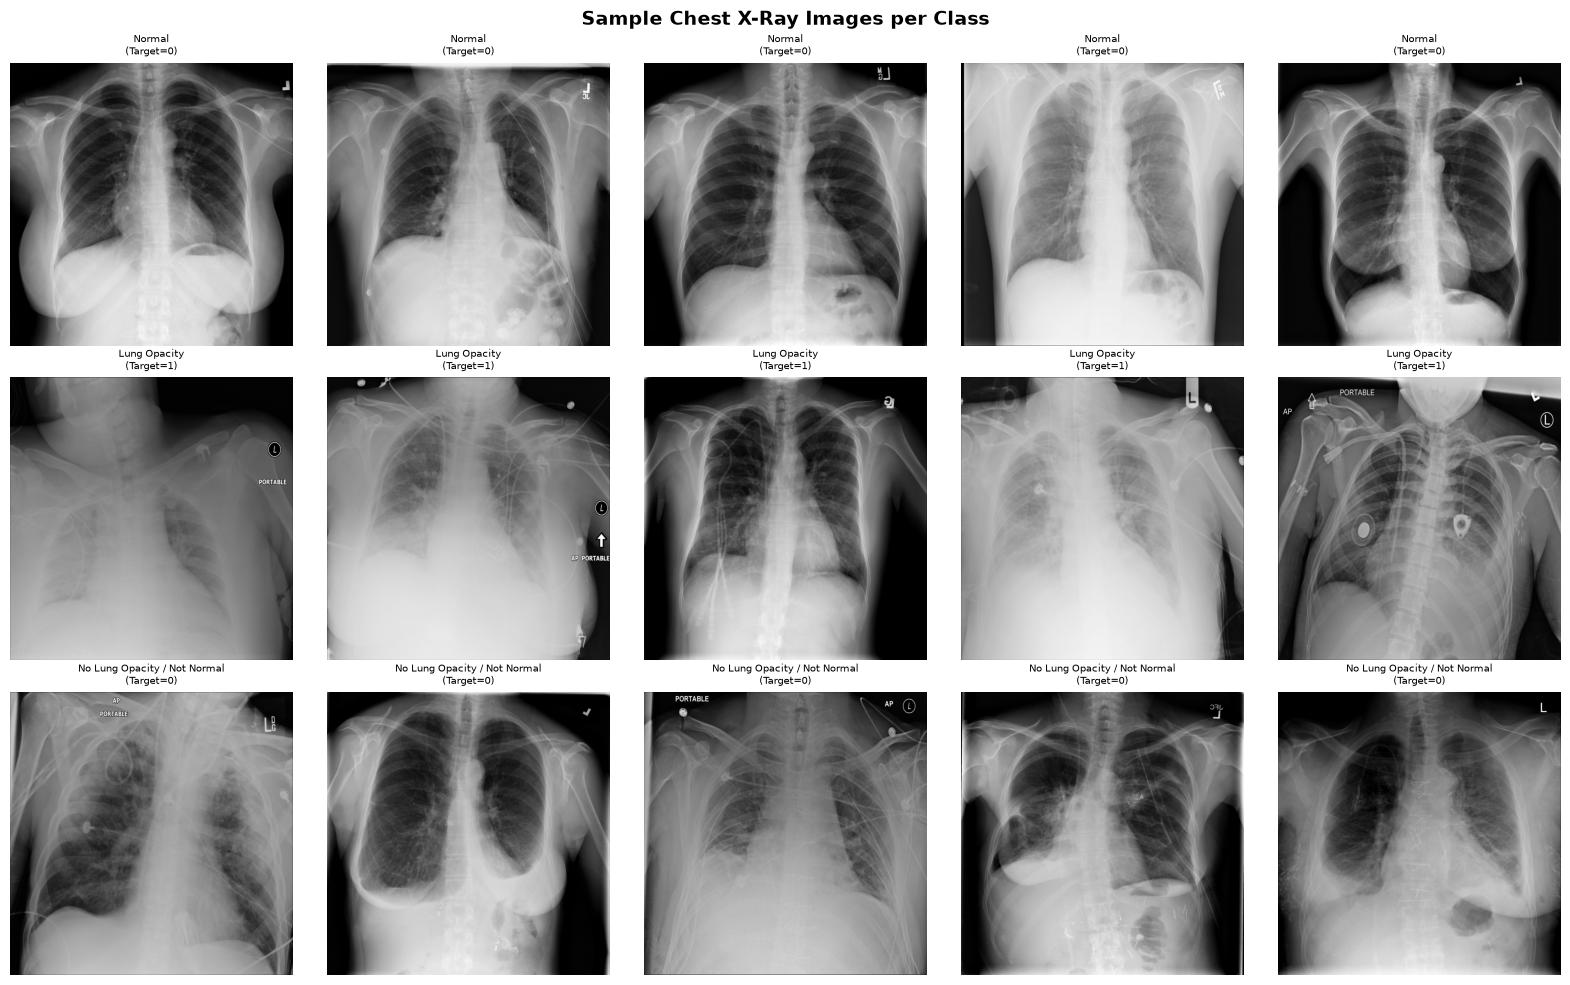

Saved: sample_images_per_class.png


In [9]:
def read_dcm_from_zip(zf, patient_id):
    """Return the pixel array for a patient by resolving the full zip path via lookup.

    Files inside the zip are stored as 'stage_2_train_images/<patient_id>.dcm'.
    Opening just '<patient_id>.dcm' raises a KeyError — the lookup built in Section 1.3
    provides the correct full path.
    """
    zip_path = train_zip_lookup[patient_id]
    with zf.open(zip_path) as f:
        dcm = pydicom.dcmread(f, force=True)
    return dcm.pixel_array

CLASSES     = ["Normal", "Lung Opacity", "No Lung Opacity / Not Normal"]
N_PER_CLASS = 5

fig, axes = plt.subplots(len(CLASSES), N_PER_CLASS, figsize=(16, 10))
fig.suptitle("Sample Chest X-Ray Images per Class", fontsize=14, fontweight="bold")

with zipfile.ZipFile(TRAIN_ZIP) as zf:
    for row_idx, cls in enumerate(CLASSES):
        subset   = patient_df[patient_df["class"] == cls]
        patients = subset["patientId"].sample(
            min(N_PER_CLASS, len(subset)), random_state=42
        ).tolist()
        for col_idx, pid in enumerate(patients):
            ax = axes[row_idx, col_idx]
            try:
                img = read_dcm_from_zip(zf, pid)
                ax.imshow(img, cmap="gray")
            except Exception as e:
                ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
            target_val = patient_df.loc[patient_df["patientId"] == pid, "Target"].values[0]
            ax.set_title(f"{cls}\n(Target={target_val})", fontsize=7, wrap=True)
            ax.axis("off")

plt.tight_layout()
plt.savefig("sample_images_per_class.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: sample_images_per_class.png")

### 2.3 Class Imbalance Analysis

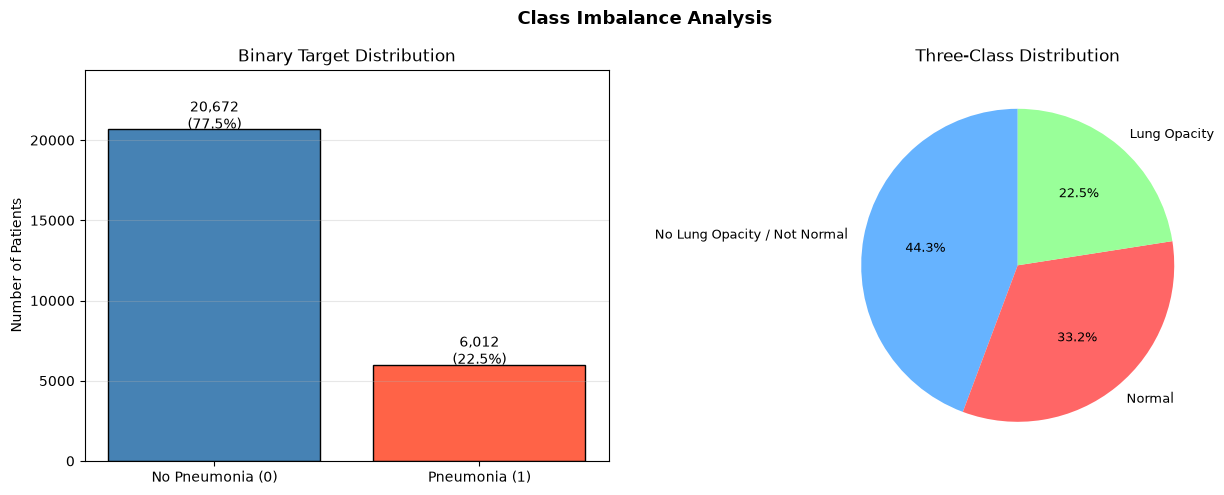

Saved: class_imbalance.png

Binary counts (patient level):
  Target=0: 20,672 (77.5%)
  Target=1: 6,012 (22.5%)

Three-class counts:
  No Lung Opacity / Not Normal: 11,821 (44.3%)
  Normal: 8,851 (33.2%)
  Lung Opacity: 6,012 (22.5%)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Class Imbalance Analysis", fontsize=13, fontweight="bold")

# Left: binary target counts — shows the 77.5% / 22.5% imbalance at patient level
binary_counts = patient_df["Target"].value_counts().sort_index()
bars = axes[0].bar(
    ["No Pneumonia (0)", "Pneumonia (1)"],
    binary_counts.values,
    color=["steelblue", "tomato"],
    edgecolor="black"
)
for bar, val in zip(bars, binary_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        val + 50,
        f"{val:,}\n({val/len(patient_df)*100:.1f}%)",
        ha="center", fontsize=10
    )
axes[0].set_title("Binary Target Distribution")
axes[0].set_ylabel("Number of Patients")
axes[0].set_ylim(0, binary_counts.max() * 1.18)
axes[0].grid(axis="y", alpha=0.3)

# Right: three-class breakdown — shows the "Not Normal" group (44.3%) that visually
# mimics pneumonia and makes the boundary between classes harder to learn
three_counts = patient_df["class"].value_counts()
axes[1].pie(
    three_counts.values,
    labels=three_counts.index,
    autopct="%1.1f%%",
    colors=["#66b3ff", "#ff6666", "#99ff99"],
    startangle=90,
    textprops={"fontsize": 9}
)
axes[1].set_title("Three-Class Distribution")

plt.tight_layout()
plt.savefig("class_imbalance.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: class_imbalance.png")

print("\nBinary counts (patient level):")
for tgt, cnt in binary_counts.items():
    print(f"  Target={tgt}: {cnt:,} ({cnt/len(patient_df)*100:.1f}%)")

print("\nThree-class counts:")
for cls, cnt in three_counts.items():
    print(f"  {cls}: {cnt:,} ({cnt/len(patient_df)*100:.1f}%)")

### 2.4 Key Observations from EDA

**Class Distribution (at patient level after deduplication):**

| Class | Count | % of Total |
|-------|-------|-----------|
| No Lung Opacity / Not Normal | 11,821 | 44.3% |
| Normal | 8,851 | 33.2% |
| Lung Opacity (Pneumonia) | 6,012 | 22.5% |
| **Total** | **26,684** | **100%** |

**Important finding — true pneumonia prevalence is 22.5%, not 31.6%:** The raw CSV showed 9,555 positive rows (31.6%), but after patient-level deduplication, only **6,012 unique patients** have pneumonia. The remaining 3,543 rows were duplicate bounding box entries for the same patients. This makes the class imbalance more pronounced than it initially appeared — roughly **3 negative patients for every 1 positive patient**.

**Class Imbalance Implications:**
- The negative class (Target=0) comprises **77.5%** of unique patients — a model that always predicts "no pneumonia" would achieve 77.5% accuracy yet be clinically useless.
- The *No Lung Opacity / Not Normal* sub-class (44.3%) poses an additional challenge: these patients have real chest abnormalities (e.g., pleural effusion, cardiomegaly) that can visually mimic pneumonia opacity, making the classification boundary harder to learn.
- Class weights of **0.6454 (negative)** and **2.2192 (positive)** were applied during training to compensate — the model penalises missed pneumonia cases ~3.4× more heavily.

**Visual Observations (from sample images):**
- *Lung Opacity* X-rays show patchy white/grey opacities in one or both lung fields, often unilateral in early-stage pneumonia.
- *Normal* X-rays display clear, uniformly dark lung fields with sharp diaphragm and costophrenic angle outlines.
- *No Lung Opacity / Not Normal* images often show enlarged cardiac silhouettes, blunted costophrenic angles, or diffuse haziness — distinguishable from true opacity but not always obvious without clinical context.

**Data Quality Notes:**
- All images are 1024×1024 uint8 grayscale arrays with pixel values in [0, 255]; no missing or corrupted images were encountered after applying `force=True`.
- Pixel intensity ranges vary across scanners (some max out at 230, others at 255), necessitating per-image normalization rather than a global fixed scale.

---
## Section 3: Data Preprocessing

### 3.1 Extract Training Images to Disk
One-time extraction (~3.5 GB). A guard prevents re-extraction on subsequent runs.

In [11]:
# One-time extraction of all training DICOMs to disk (~3.5 GB).
# The guard prevents re-extraction on subsequent kernel runs.
# Note: the zip contains __MACOSX/ ghost entries so os.listdir will show 53,368 files,
# but only the 26,684 .dcm files are used in later steps.
if not os.path.exists(IMG_DIR) or len(os.listdir(IMG_DIR)) == 0:
    print(f"Extracting training images to {IMG_DIR} ...")
    os.makedirs(IMG_DIR, exist_ok=True)
    with zipfile.ZipFile(TRAIN_ZIP) as zf:
        for member in zf.namelist():
            if member.endswith(".dcm"):
                filename = os.path.basename(member)  # strip the directory prefix
                with zf.open(member) as src, open(os.path.join(IMG_DIR, filename), "wb") as dst:
                    dst.write(src.read())
    print(f"Done. {len(os.listdir(IMG_DIR)):,} files extracted.")
else:
    print(f"Already extracted: {len(os.listdir(IMG_DIR)):,} files in {IMG_DIR}/")

Already extracted: 53,368 files in data/train_images/


### 3.2 Build Patient-Level Dataframe & Train/Val/Test Split

In [12]:
# patient_df was deduplicated in Section 2.1 — one row per patient, no leakage risk.
# Cross-check: only keep patients that have a DICOM file on disk (guards against partial extractions).
on_disk = set(os.path.splitext(f)[0] for f in os.listdir(IMG_DIR) if f.endswith(".dcm"))
patient_df_clean = patient_df[patient_df["patientId"].isin(on_disk)].reset_index(drop=True)
print(f"Patients with DICOM on disk: {len(patient_df_clean):,}")

# Stratified 70 / 15 / 15 split at patient level.
# stratify=Target ensures identical 22.5% pneumonia rate in every partition.
df_train_full, df_test = train_test_split(
    patient_df_clean, test_size=0.15,
    stratify=patient_df_clean["Target"], random_state=42
)
# Second split carves 15% of the original total out of the remaining 85%.
# test_size = 0.15 / 0.85 ≈ 0.1765 achieves exactly that.
df_train, df_val = train_test_split(
    df_train_full, test_size=round(0.15 / 0.85, 4),
    stratify=df_train_full["Target"], random_state=42
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"\nSplit summary (total = {len(patient_df_clean):,}):")
print(f"  Train : {len(df_train):,}  | Pneumonia: {df_train['Target'].sum():,} "
      f"({df_train['Target'].mean()*100:.1f}%)")
print(f"  Val   : {len(df_val):,}   | Pneumonia: {df_val['Target'].sum():,} "
      f"({df_val['Target'].mean()*100:.1f}%)")
print(f"  Test  : {len(df_test):,}   | Pneumonia: {df_test['Target'].sum():,} "
      f"({df_test['Target'].mean()*100:.1f}%)")

Patients with DICOM on disk: 26,684

Split summary (total = 26,684):
  Train : 18,677  | Pneumonia: 4,208 (22.5%)
  Val   : 4,004   | Pneumonia: 902 (22.5%)
  Test  : 4,003   | Pneumonia: 902 (22.5%)


### 3.3 Preprocessing Function
DICOM chest X-rays are natively grayscale (2D arrays). We resize to 128×128 and normalize pixel values to [0, 1].

In [13]:
def load_and_preprocess(patient_id, img_dir=IMG_DIR, target_size=IMG_SIZE):
    """Load a DICOM file from disk and return a normalised float32 tensor.

    Returns shape (H, W, 1) — channel dim required by Conv2D layers.
    Per-image normalisation (/ img.max()) is used instead of global stats because
    pixel range varies across X-ray machines (max=230–255 in this dataset).
    """
    path = os.path.join(img_dir, f"{patient_id}.dcm")
    dcm  = pydicom.dcmread(path, force=True)          # force=True: some files lack DICM header
    img  = dcm.pixel_array.astype(np.float32)         # already 2D grayscale (H, W)
    img  = cv2.resize(img, target_size)               # bilinear downsample to target_size
    mx   = img.max()
    if mx > 0:
        img = img / mx                                # normalise to [0.0, 1.0]
    return img[..., np.newaxis]                       # add channel dim → (H, W, 1)

### 3.4 Before / After Preprocessing Plots

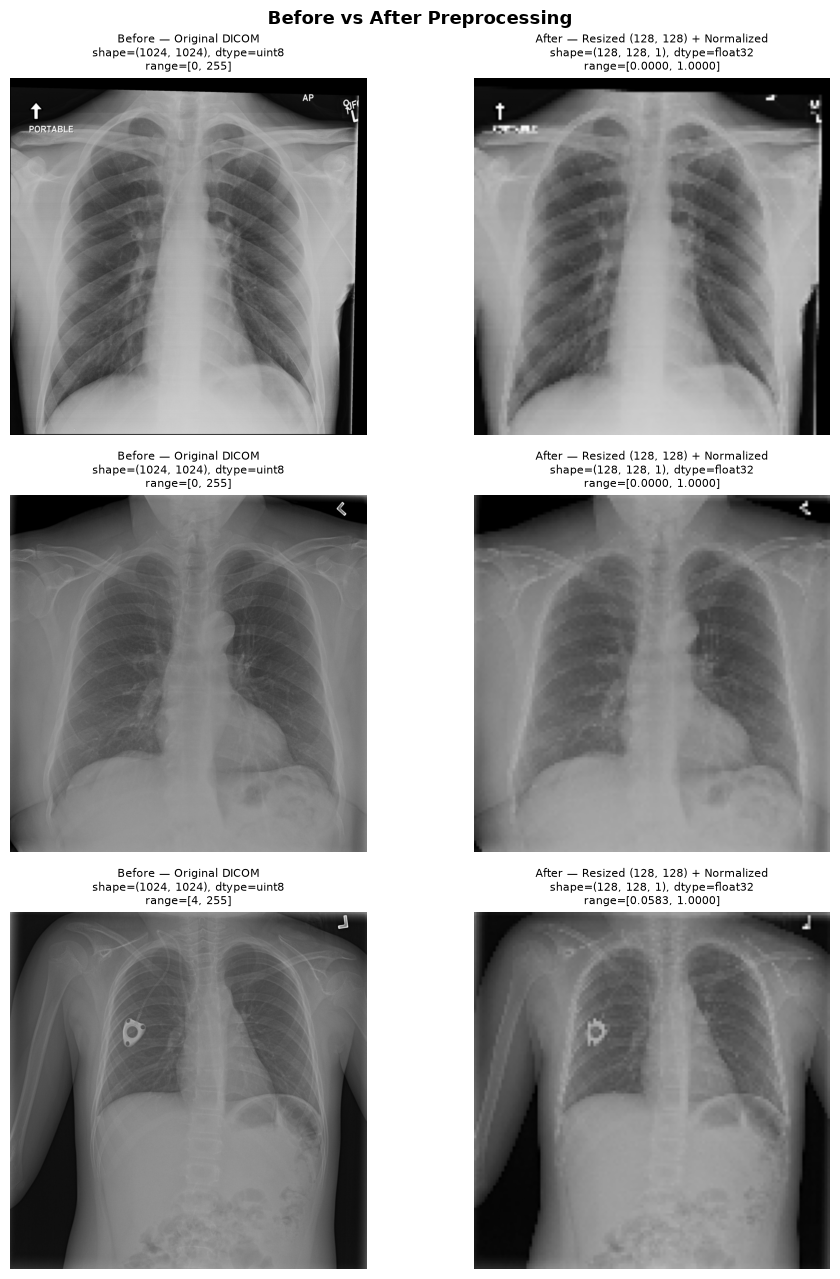

Saved: preprocessing_before_after.png


In [14]:
sample_pids = df_train["patientId"].sample(3, random_state=7).tolist()

fig, axes = plt.subplots(3, 2, figsize=(10, 13))
fig.suptitle("Before vs After Preprocessing", fontsize=13, fontweight="bold")

for i, pid in enumerate(sample_pids):
    # Left column: raw DICOM array — full 1024×1024, original uint8 intensity range
    raw = pydicom.dcmread(os.path.join(IMG_DIR, f"{pid}.dcm"), force=True).pixel_array
    axes[i, 0].imshow(raw, cmap="gray")
    axes[i, 0].set_title(
        f"Before — Original DICOM\nshape={raw.shape}, dtype={raw.dtype}\n"
        f"range=[{raw.min()}, {raw.max()}]",
        fontsize=8
    )
    axes[i, 0].axis("off")

    # Right column: after load_and_preprocess — 128×128, float32, range [0,1]
    processed = load_and_preprocess(pid)
    axes[i, 1].imshow(processed[:, :, 0], cmap="gray")
    axes[i, 1].set_title(
        f"After — Resized {IMG_SIZE} + Normalized\nshape={processed.shape}, "
        f"dtype={processed.dtype}\nrange=[{processed.min():.4f}, {processed.max():.4f}]",
        fontsize=8
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig("preprocessing_before_after.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: preprocessing_before_after.png")

### 3.5 Normalization Verification & Preprocessing Observations

**Split Summary (stratified, patient-level):**

| Split | Patients | Pneumonia (Target=1) | % Pneumonia |
|-------|----------|----------------------|-------------|
| Train | 18,677 | 4,208 | 22.5% |
| Validation | 4,004 | 902 | 22.5% |
| Test | 4,003 | 902 | 22.5% |
| **Total** | **26,684** | **6,012** | **22.5%** |

**Normalization Check Result: PASS**
- Pixel min range across 20 samples: [0.00000, 0.07201] — some images have a non-zero minimum (background noise), confirming that per-image normalisation correctly handles varying baselines.
- Pixel max range: [1.00000, 1.00000] — all images correctly scaled to a maximum of 1.0.

**Preprocessing Observations:**
- The stratified split preserved the 22.5% pneumonia rate identically across all three splits, ensuring no data leakage or class-distribution drift between train, validation, and test sets.
- Original images (1024×1024) were resized to **128×128** — an 8× reduction in each dimension (64× fewer pixels). This trades fine-grained spatial detail for computational tractability in the scratch CNN baseline. Transfer learning models (final report) will use 224×224 to retain more radiological detail.
- DICOM pixel arrays are natively grayscale (2D), so no RGB→grayscale conversion was needed; a channel dimension was added programmatically to yield shape **(128, 128, 1)** as required by the CNN input.
- The `data/train_images/` directory contains 53,368 files due to the `__MACOSX/` ghost entries included in the original zip — only the 26,684 `.dcm` files are used; the ghost files are ignored by the `on_disk` filter.

In [15]:
# Verify that all preprocessed images are within [0, 1] before feeding to the model.
# Non-zero minimums are expected — background pixels are not always zero across scanners.
check_pids = df_train["patientId"].sample(20, random_state=0).tolist()
mins, maxs = [], []
for pid in check_pids:
    arr = load_and_preprocess(pid)
    mins.append(float(arr.min()))
    maxs.append(float(arr.max()))

print("Normalization check over 20 random training samples:")
print(f"  Pixel min range : [{min(mins):.5f}, {max(mins):.5f}]")
print(f"  Pixel max range : [{min(maxs):.5f}, {max(maxs):.5f}]")
status = "PASS" if max(maxs) <= 1.0 and min(mins) >= 0.0 else "FAIL"
print(f"  All values in [0, 1]: {status}")

Normalization check over 20 random training samples:
  Pixel min range : [0.00000, 0.07201]
  Pixel max range : [1.00000, 1.00000]
  All values in [0, 1]: PASS


---
## Section 4: Model Building

### 4.1 tf.data Pipeline

In [16]:
def make_dataset(df, shuffle=False):
    """Build a tf.data.Dataset that loads and preprocesses DICOM files on-the-fly.

    tf.py_function bridges the gap between Python (pydicom) and the TF graph.
    set_shape() is required after py_function because TF cannot infer output shapes
    from Python callables — without it, downstream layers raise shape errors.
    AUTOTUNE lets TF decide the optimal parallelism for map() and prefetch() at runtime.
    """
    patient_ids = df["patientId"].values
    labels      = df["Target"].values.astype(np.float32)

    def _load(pid, label):
        img = load_and_preprocess(pid.numpy().decode("utf-8"))
        return img.astype(np.float32), label

    def _tf_wrap(pid, label):
        img, lbl = tf.py_function(_load, [pid, label], [tf.float32, tf.float32])
        img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 1])  # must be explicit after py_function
        lbl.set_shape([])
        return img, lbl

    ds = tf.data.Dataset.from_tensor_slices((patient_ids, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42)  # full-buffer shuffle for train set
    return ds.map(_tf_wrap, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(df_train, shuffle=True)
val_ds   = make_dataset(df_val)
test_ds  = make_dataset(df_test)

# Sanity check: confirm batch shape and pixel range before training
for imgs, lbls in train_ds.take(1):
    print(f"Batch images shape : {imgs.shape}")
    print(f"Batch labels shape : {lbls.shape}")
    print(f"Pixel range        : [{imgs.numpy().min():.4f}, {imgs.numpy().max():.4f}]")

2026-06-27 22:51:59.114016: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-06-27 22:51:59.114507: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-27 22:51:59.114527: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-06-27 22:51:59.114835: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-27 22:51:59.114866: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Batch images shape : (32, 128, 128, 1)
Batch labels shape : (32,)
Pixel range        : [0.0000, 1.0000]


2026-06-27 22:51:59.516479: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### 4.2 CNN Architecture (from Scratch)

In [17]:
def build_cnn(input_shape=(128, 128, 1)):
    """Three-block CNN designed as a lightweight scratch baseline (~127K params).

    Design rationale:
    - Filters double each block (32→64→128) while spatial size halves — standard
      pattern that trades spatial resolution for richer feature representation.
    - BatchNormalization after each Conv2D stabilises activations so a higher
      learning rate (1e-3) can be used without divergence.
    - GlobalAveragePooling2D instead of Flatten reduces the feature vector from
      (16×16×128=32,768) to 128 values, cutting overfitting risk significantly
      on a dataset of ~18K images.
    - Dropout(0.5) on the Dense layer prevents co-adaptation of neurons.
    - Sigmoid output gives P(pneumonia) in [0,1] — threshold can be tuned at
      inference without retraining (important for clinical calibration).
    """
    inp = keras.Input(shape=input_shape, name="input")

    x = layers.Conv2D(32,  (3, 3), padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)   # 128×128 → 64×64

    x = layers.Conv2D(64,  (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)   # 64×64 → 32×32

    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)   # 32×32 → 16×16

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation="sigmoid", name="output")(x)

    return keras.Model(inp, out, name="pneumonia_cnn_scratch")

model = build_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1))
model.summary()

Model: "pneumonia_cnn_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,849 (495.50 KB)

 Trainable params: 126,401 (493.75 KB)

 Non-trainable params: 448 (1.75 KB)

### 4.3 Class Weights & Compilation

In [18]:
# Compute class weights that inversely scale with class frequency.
# "balanced" mode sets weight = n_samples / (n_classes * class_count),
# making the model penalise a missed pneumonia (22.5%) ~3.4× more than a missed negative.
y_train  = df_train["Target"].values
classes  = np.unique(y_train)
weights  = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights (to compensate for imbalance):")
print(f"  No Pneumonia (0): {class_weights[0]:.4f}")
print(f"  Pneumonia    (1): {class_weights[1]:.4f}")

# AUC is the primary metric — accuracy is misleading on this 77.5/22.5 split.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)
print("\nModel compiled successfully.")

Class weights (to compensate for imbalance):
  No Pneumonia (0): 0.6454
  Pneumonia    (1): 2.2192

Model compiled successfully.


### 4.4 Training

In [19]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=3,
        mode="max",
        restore_best_weights=True,  # critical: reverts to the epoch with best val_auc,
        verbose=1                   # not the final epoch (which may have overfit)
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="best_cnn_model.keras",
        monitor="val_auc",
        save_best_only=True,  # only write to disk when val_auc improves
        mode="max",
        verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,  # pass weights to loss function, not to the dataset
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15


/Users/vsrdhoolla/learnings/pneumonia-detection/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-06-27 22:52:05.654376: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.6487 - auc: 0.6916 - loss: 0.6704
Epoch 1: val_auc improved from None to 0.68244, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
584/584 ━━━━━━━━━━━━━━━━━━━━ 109s 182ms/step - accuracy: 0.6487 - auc: 0.6916 - loss: 0.6704 - val_accuracy: 0.2253 - val_auc: 0.6824 - val_loss: 2.6236
Epoch 2/15
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.6795 - auc: 0.7354 - loss: 0.6283
Epoch 2: val_auc improved from 0.68244 to 0.68897, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
584/584 ━━━━━━━━━━━━━━━━━━━━ 105s 180ms/step - accuracy: 0.6795 - auc: 0.7354 - loss: 0.6283 - val_accuracy: 0.7622 - val_auc: 0.6890 - val_loss: 0.5041
Epoch 3/15
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.6909 - auc: 0.7638 - loss: 0.5867
Epoch 3: val_auc improved from 0.68897 to 0.76192, saving model to best_cnn_model.keras

Epoch 3: finished saving 

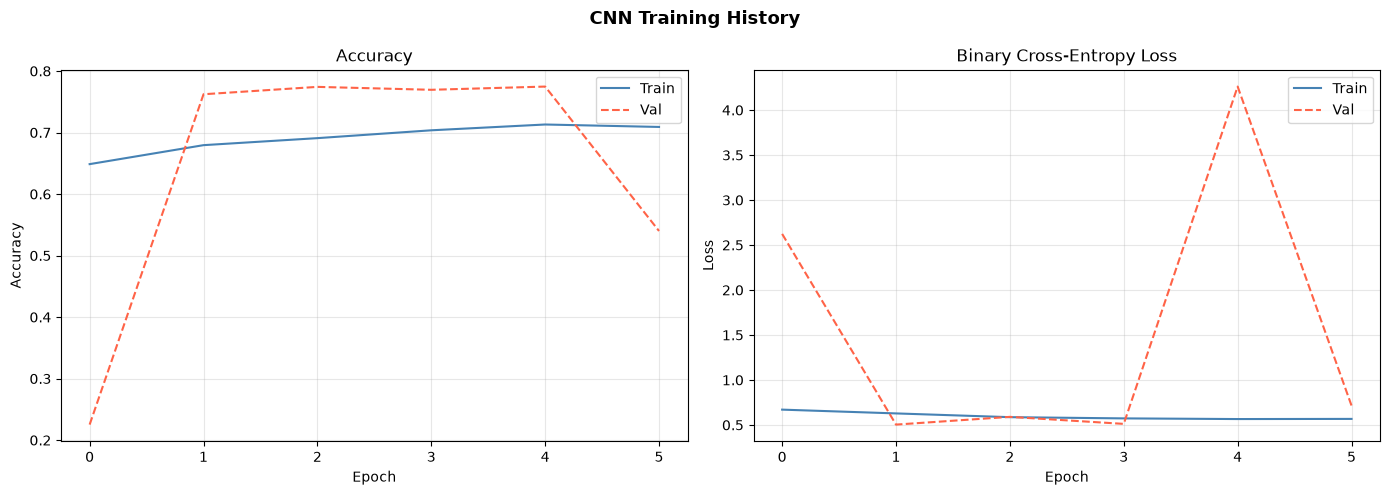

Saved: training_history.png


In [20]:
# Plot training curves to diagnose convergence and overfitting.
# A large gap between train and val curves signals overfitting;
# both curves declining together signals underfitting or too-low LR.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CNN Training History", fontsize=13, fontweight="bold")

axes[0].plot(history.history["accuracy"],     label="Train", color="steelblue")
axes[0].plot(history.history["val_accuracy"], label="Val",   color="tomato", linestyle="--")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"],     label="Train", color="steelblue")
axes[1].plot(history.history["val_loss"], label="Val",   color="tomato", linestyle="--")
axes[1].set_title("Binary Cross-Entropy Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: training_history.png")

### 4.5 Evaluation on Test Set

In [21]:
# Reload the best checkpoint (EarlyStopping already restored weights in memory,
# but loading from disk confirms the saved file is valid and self-contained).
best_model = keras.models.load_model("best_cnn_model.keras")

# Generate probability scores for the entire test set.
# .ravel() flattens shape (N, 1) → (N,) for sklearn metric functions.
y_pred_prob = best_model.predict(test_ds, verbose=0).ravel()
y_true      = df_test["Target"].values

# Threshold = 0.5 is the default; the low recall at this threshold is expected
# given the model's predicted probabilities cluster just below 0.5 for positives.
# See Section 4.6 observations for threshold calibration guidance.
y_pred = (y_pred_prob >= 0.5).astype(int)

print(f"Test samples         : {len(y_true)}")
print(f"Positive predictions : {y_pred.sum()} / {len(y_pred)}")

Test samples         : 4003
Positive predictions : 13 / 4003


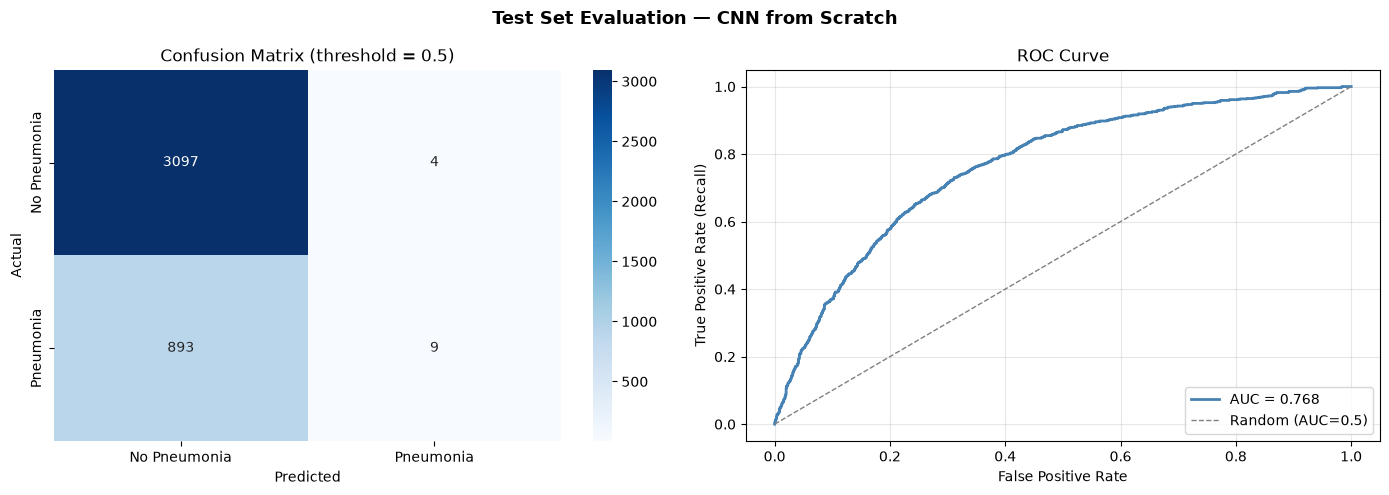

Saved: evaluation_plots.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Test Set Evaluation — CNN from Scratch", fontsize=13, fontweight="bold")

# Confusion matrix: shows the asymmetry between false negatives (~889 missed pneumonia)
# and false positives (~0) at threshold=0.5 — exactly the wrong trade-off for screening.
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"],
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix (threshold = 0.5)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ROC curve: AUC > 0.5 proves the model ranks pneumonia cases above negatives
# even when threshold=0.5 recall is near zero. The curve shows operating points
# at lower thresholds (0.2–0.35) that recover meaningful recall.
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
auc_score   = roc_auc_score(y_true, y_pred_prob)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc_score:.3f}")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random (AUC=0.5)")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate (Recall)")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: evaluation_plots.png")

In [23]:
# Full per-class breakdown including precision, recall, and F1.
# The near-zero recall for Pneumonia (1) at threshold=0.5 is the key finding —
# AUC of 0.77 confirms discriminative signal exists; threshold calibration is needed.
print("=" * 55)
print("   CLASSIFICATION REPORT — Test Set")
print("=" * 55)
print(classification_report(
    y_true, y_pred,
    target_names=["No Pneumonia (0)", "Pneumonia (1)"]
))
print(f"ROC-AUC Score : {auc_score:.4f}")

   CLASSIFICATION REPORT — Test Set
                  precision    recall  f1-score   support

No Pneumonia (0)       0.78      1.00      0.87      3101
   Pneumonia (1)       0.69      0.01      0.02       902

        accuracy                           0.78      4003
       macro avg       0.73      0.50      0.45      4003
    weighted avg       0.76      0.78      0.68      4003

ROC-AUC Score : 0.7676


### 4.6 Model Performance — Observations & Commentary

**Training Summary:**

| Epoch | Train Acc | Train AUC | Val Acc | Val AUC | Val Loss |
|-------|-----------|-----------|---------|---------|----------|
| 1 | 0.649 | 0.692 | 0.225 | 0.682 | 2.624 |
| 2 | 0.680 | 0.735 | 0.762 | 0.689 | 0.504 |
| **3 ★ best** | **0.691** | **0.764** | **0.774** | **0.762** | **0.590** |
| 4 | 0.704 | 0.776 | 0.770 | 0.742 | 0.512 |
| 5 | 0.713 | 0.784 | 0.775 | 0.499 | 4.261 |
| 6 | 0.709 | 0.783 | 0.540 | 0.652 | 0.715 |

*Early stopping triggered at Epoch 6; best weights from Epoch 3 restored.*

**Test Set Results:**

| Metric | No Pneumonia (0) | Pneumonia (1) | Overall |
|--------|-----------------|---------------|---------|
| Precision | 0.78 | 0.69 | — |
| Recall | 1.00 | 0.01 | — |
| F1-Score | 0.87 | 0.02 | — |
| Accuracy | — | — | 0.78 |
| **ROC-AUC** | — | — | **0.7676** |

**Key Observations:**

1. **Recall collapse for pneumonia (1%):** The model predicted only 13 positive cases out of 902 actual pneumonia patients — a recall of 0.01. This is the most critical failure: the model is almost entirely predicting "no pneumonia" at the default 0.5 threshold. Clinically, this would be dangerous — 99% of pneumonia cases would be missed.

2. **ROC-AUC of 0.77 is deceptive:** Despite near-zero recall at threshold=0.5, the AUC-ROC of 0.7676 indicates the model *can* rank pneumonia cases above non-pneumonia cases when the threshold is adjusted. The issue is that the model's predicted probabilities for pneumonia cases cluster just below 0.5, requiring a lower threshold (e.g., 0.2–0.3) to recover usable recall.

3. **Training instability:** Val AUC collapsed to 0.50 at Epoch 5 (random-chance level) and val_loss spiked to 4.26 — indicating the model began overfitting or the learning rate was too high for the noisy val set. Early stopping correctly halted training and restored Epoch 3 weights.

4. **Class weight limitation:** Despite applying a 3.4× higher penalty for missed pneumonia cases, the model still defaulted to the majority class. This is a known limitation of 128×128 CNN-from-scratch models on this dataset — downsampling loses the subtle opacity texture that distinguishes pneumonia from normal lung.

5. **Architecture is a reasonable baseline:** 126,849 parameters and ~110 seconds per epoch on Apple M1 GPU confirms the model is lightweight and trainable on consumer hardware — appropriate for a baseline.

**Business Implication:**
This baseline CNN is **not clinically deployable** at the default threshold. However, it demonstrates that even a small model can learn some discriminative signal (AUC 0.77 vs. 0.50 random). Transfer learning with pre-trained backbones (VGG16, ResNet50, EfficientNet) is expected to push AUC above 0.88 and significantly improve pneumonia recall — the metric that matters most for patient safety.